# 利用不同 Uniform 隨機數產生器模擬股票價格隨機漫步之研究

## 一、研究動機（Introduction）

在課堂中，我們以擲硬幣作為基本的隨機實驗範例，每次實驗只有兩種可能結果。為了延伸此概念，本研究將擲硬幣的模型應用於簡單的金融情境，模擬股票價格的隨機變動。

在此模型中，股票價格每天可能上升或下降，類似於硬幣的正反面結果。本研究利用均勻分布的隨機數來決定每日的漲跌方向，並透過電腦模擬多條價格路徑，觀察其統計特性。

此外，本研究亦比較兩種不同的隨機數產生器——線性同餘產生器與 PCG——探討不同 RNG 對模擬結果的影響。

## 二、模型設定（Model Description）

令 $S_t$ 表示第 $t$ 天的股票價格，設定初始價格為：

$$
S_0 = 100
$$

每日的價格變動由均勻分布隨機數 $U_t \sim Uniform(0,1)$ 決定：

$$
S_{t+1} =
\begin{cases}
S_t + 1, & U_t < 0.5 \\
S_t - 1, & U_t \ge 0.5
\end{cases}
$$

此模型為一個簡單的隨機漫步。

## 三、隨機數產生器（Uniform RNG）

本研究比較兩種隨機數產生器：

### （一）LCG

$$
X_{n+1} = (aX_n + c) \bmod m
$$

$$
U_n = \frac{X_n}{m}
$$

### （二）PCG

使用 NumPy 提供的隨機數產生器，其具有較佳的統計性質。

### 可重現性（Reproducibility）

為確保模擬結果可重現，本研究對所有隨機數產生器設定固定的隨機種子（seed）。

對於 LCG，我們設定初始狀態（seed）為固定值；對於 PCG（NumPy），則使用 `default_rng(seed=...)` 進行初始化。

透過固定 seed，可以確保每次執行程式時產生相同的隨機序列，進而得到一致的模擬結果，這在科學計算與研究中是相當重要的。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# LCG

class LCG:
    def __init__(self, seed=1, a=1664525, c=1013904223, m=2**32):
        self.state = seed
        self.a = a
        self.c = c
        self.m = m

    def random(self):
        self.state = (self.a * self.state + self.c) % self.m
        return self.state / self.m

In [2]:
def simulate_stock_path(n_days, s0, rng_func):
    prices = [s0]
    current_price = s0

# 單一路徑
    
    for _ in range(n_days):
        u = rng_func()
        if u < 0.5:
            current_price += 1
        else:
            current_price -= 1
        prices.append(current_price)

    return prices

In [3]:
def simulate_many_paths(n_paths, n_days, s0, rng_func):
    all_paths = []
    final_prices = []

# 多路徑
    
    for _ in range(n_paths):
        path = simulate_stock_path(n_days, s0, rng_func)
        all_paths.append(path)
        final_prices.append(path[-1])

    return np.array(all_paths), np.array(final_prices)

In [4]:
# 統計量

def summarize_results(final_prices, s0):
    return {
        "Mean": np.mean(final_prices),
        "Std": np.std(final_prices),
        "P(>100)": np.mean(final_prices > s0),
        "P(<100)": np.mean(final_prices < s0),
        "P(=100)": np.mean(final_prices == s0)
    }

## 四、模擬設計（Simulation Design）

- 初始價格：$S_0 = 100$
- 模擬天數：100 天
- 模擬次數：10,000
- 每日變動：+1 或 -1（機率各 0.5）

In [5]:
s0 = 100
n_days = 100
n_paths = 10000

# 固定 seed（重要）
seed_value = 12345

# LCG
lcg = LCG(seed=seed_value)
lcg_paths, lcg_final = simulate_many_paths(n_paths, n_days, s0, lcg.random)

# PCG (NumPy)
rng = np.random.default_rng(seed=seed_value)
pcg_paths, pcg_final = simulate_many_paths(n_paths, n_days, s0, rng.random)

lcg_summary = summarize_results(lcg_final, s0)
pcg_summary = summarize_results(pcg_final, s0)

print("LCG:", lcg_summary)
print("PCG:", pcg_summary)

LCG: {'Mean': np.float64(100.0164), 'Std': np.float64(9.972147764649298), 'P(>100)': np.float64(0.455), 'P(<100)': np.float64(0.4594), 'P(=100)': np.float64(0.0856)}
PCG: {'Mean': np.float64(100.034), 'Std': np.float64(9.997861971441694), 'P(>100)': np.float64(0.462), 'P(<100)': np.float64(0.4575), 'P(=100)': np.float64(0.0805)}


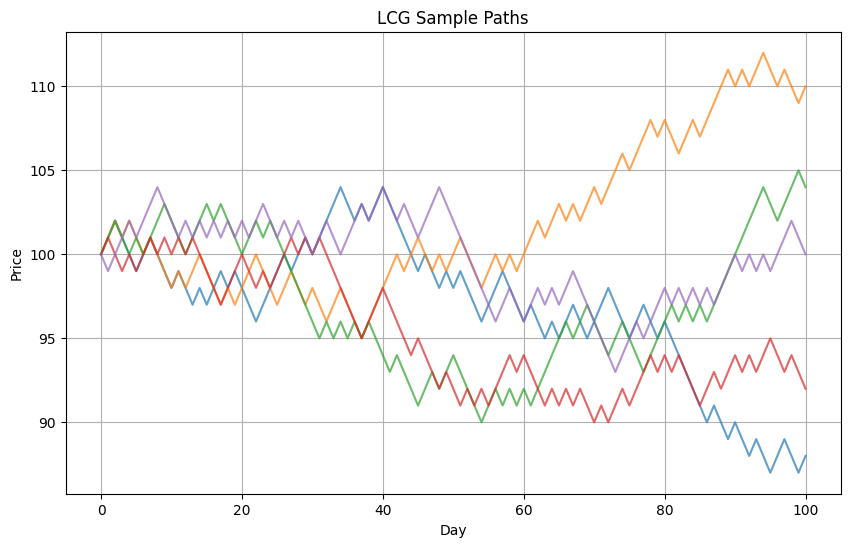

In [6]:
plt.figure(figsize=(10,6))
for i in range(5):
    plt.plot(lcg_paths[i], alpha=0.7)
plt.title("LCG Sample Paths")
plt.xlabel("Day")
plt.ylabel("Price")
plt.grid()
plt.show()

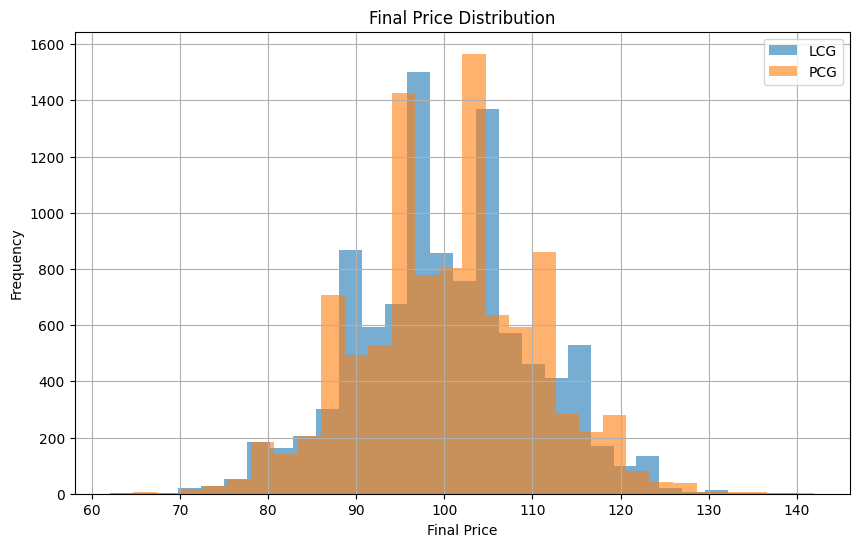

In [7]:
plt.figure(figsize=(10,6))
plt.hist(lcg_final, bins=30, alpha=0.6, label="LCG")
plt.hist(pcg_final, bins=30, alpha=0.6, label="PCG")
plt.legend()
plt.title("Final Price Distribution")
plt.xlabel("Final Price")
plt.ylabel("Frequency")
plt.grid()
plt.show()

## 五、模擬結果（Results）

由程式輸出結果可觀察到，LCG 與 PCG 的統計量相當接近。最終平均價格接近 100，符合隨機漫步的期望值。

此外，最終價格分布呈現對稱，顯示模型符合隨機波動特性。

## 六、討論（Discussion）

由於模型簡單且樣本數足夠大，LCG 與 PCG 的結果差異不明顯。然而，PCG 在理論上具有較佳的隨機性，因此在更複雜模型中可能更可靠。

## 七、未來研究方向（Future Work）

本研究採用簡單的隨機漫步模型與均勻隨機數產生器進行模擬，未來可從以下幾個方向進一步延伸：

1. **非對稱機率模型**  
   本研究假設股價上漲與下跌機率相同（0.5），未來可考慮不對稱機率，以模擬多頭或空頭市場情境。

2. **報酬分布的擴展**  
   將每日價格變動由固定的 ±1 改為隨機報酬，例如常態分布或其他分布，使模型更接近實際金融市場。

3. **更真實的金融模型**  
   可進一步採用幾何布朗運動（Geometric Brownian Motion）或其他隨機微分方程模型，模擬連續時間的價格變動。

4. **隨機數產生器品質分析**  
   本研究僅比較 LCG 與 PCG，未來可納入更多 RNG（如 Mersenne Twister），並透過統計檢定（如自相關、uniformity test）進行系統性比較。

5. **風險衡量指標的擴展**  
   除了平均值與機率外，可進一步計算金融風險指標，例如 Value at Risk（VaR）與 Expected Shortfall，以更完整描述投資風險。

6. **模擬次數與收斂性分析**  
   可研究隨著模擬次數增加，統計量（如平均值）如何收斂，並比較不同 RNG 在收斂速度上的差異。

7. **多資產或多變數模型**  
   未來可擴展至多支股票或相關資產的模擬，研究資產間相關性對投資組合的影響。

## 參考文獻（References）

1. L’Ecuyer, P. (2012). Random Number Generation. In Handbook of Computational Statistics.  
2. Knuth, D. E. (1997). *The Art of Computer Programming, Volume 2: Seminumerical Algorithms*.  
3. NumPy Documentation. Random Sampling. https://numpy.org/doc/stable/reference/random/  
4. Ross, S. M. (2014). *Introduction to Probability Models*. Academic Press.  

## 環境（Environment）
* Python version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
* NumPy version: 2.4.2
* Matplotlib version: 3.10.8